# HAR-SSM Corrector — Repair and Re-test

One innovation on top of the frozen-core two-stage framework: the **HAR-SSM corrector**, a diagonal
*selective* SSM whose per-channel state-decay rates are **initialised at the HAR half-lives
(1 / 5 / 22 days)** and stay learnable (Mamba-style input-dependent gating on top, `half_lives()`
readout for interpretability).

**Why this run exists.** The first attempt showed no significant improvement over the plain
BI-Mamba hybrid *and* the learned half-lives had ~zero IQR within each init-group — every channel
in a group shifted identically (e.g. 5.00 → 4.91), which is the signature of uniform weight decay
acting on the decay-rate parameter `b_dt`, not of a learned, data-driven half-life. That means the
corrector's key dial was effectively frozen and the idea was never actually tested. Fix applied
here: `b_dt` gets its own optimizer param group with `weight_decay=0` (and a higher LR, since it's a
scalar-per-channel physical parameter that sees small gradients) — everything else is unchanged. A
gradient-norm probe on `b_dt` is printed during training so the fix can be verified directly rather
than inferred after the fact.

Rows per index: `Hybrid (BI-Mamba)` (reference) · `Hybrid (HAR-SSM)`. DM on the decisive pairs only.


## 0 — Setup
Put `IXIC_vol.csv`, `NYA_vol.csv`, `DJI_vol.csv` (from `build_vol_dataset.py`) in the working directory.

In [1]:
import os
EXPECTED = ["IXIC_vol.csv", "NYA_vol.csv", "DJI_vol.csv"]
missing = [f for f in EXPECTED if not os.path.exists(f)]
print("found:", [f for f in EXPECTED if os.path.exists(f)])
if missing:
    print("MISSING:", missing, "\n-> upload them, or run build_vol_dataset.py first (needs internet):")
    print("   !pip install -q yfinance && python build_vol_dataset.py  (then move vol_dataset/*.csv here)")

found: ['IXIC_vol.csv', 'NYA_vol.csv', 'DJI_vol.csv']


In [2]:
import math, random, copy
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| torch", torch.__version__)
if DEVICE == "cuda": print("gpu:", torch.cuda.get_device_name(0))

## 1 — Config
Every experiment is one `Config`. All ablation knobs below are implemented.

In [3]:
INDICES = ["DJI", "IXIC", "NYA"]        # all three are run; put <IDX>_vol.csv files next to the notebook

@dataclass
class Config:
    data_path: str = "DJI_vol.csv"                     # overridden per index by the runner
    target_col: str = "target_logrv"                    # log realized vol over the next `target_horizon` days
    not_features: List[str] = field(default_factory=lambda: ["Close", "target_logrv", "target_rv"])
    target_horizon: int = 5                             # h used to BUILD the target/baselines (must match build_vol_dataset.py)

    seq_in: int = 60                                    # long lookback: volatility has long memory
    horizon: int = 1                                    # model output dim (one target per sample)
    val_ratio: float = 0.15; test_ratio: float = 0.15

    d_model: int = 32; n_layer: int = 3; d_state: int = 128; expand: int = 2; d_conv: int = 3
    dt_rank: Optional[int] = None                       # None -> ceil(d_model/16)
    cheb_k: int = 3; embed: int = 10; hid: int = 32
    scan_chunk: int = 32                                # parallel-scan chunk (>= seq_len => single fully-parallel scan)

    batch_size: int = 32; epochs: int = 100; lr: float = 1e-3; weight_decay: float = 1e-4
    grad_clip: float = 5.0; patience: int = 15

    # ----- ablation knobs (pure BI-Mamba) -----
    scan_axis: str = "time"                             # "time" (baseline) | "feature" (variate-as-token)
    n_scans: int = 2                                    # 2 = bidirectional; >2 adds permuted scans
    use_registers: bool = False; n_registers: int = 4
    reg_control: bool = False                           # param-matched control for the register readout
    grad_checkpoint: bool = False                       # recompute scan in backward -> big GPU-memory saving on heavy rows
    hybrid: bool = False                                # add the HAR-X+VIX+GARCH core; BI-Mamba models the residual
    freeze_core: bool = True                            # lock the core to its OLS fit (two-stage) so you can't do worse than it
    corrector: str = "bimamba"                          # corrector backbone: bimamba | lstm | gru | mlp | harssm (param-matched)
    halflife_init: str = "har"                          # HAR-SSM init: har (1/5/22d groups) | flat10 (all 10d) | random (U[2,15]d)
    input_fusion: bool = False                          # Kim&Won-style: core predictors appended to network INPUTS (use with hybrid=False)
    core_set: str = "full"                              # core composition: full | har | har_iv | har_garch
    qlike_align: bool = False                           # train & early-stop on QLIKE (variance loss) instead of MSE/RMSE
    cross_market: bool = False                          # input = features of ALL three indices (spillover); target stays this index
    cross_paths: List[str] = field(default_factory=lambda: ["DJI_vol.csv", "IXIC_vol.csv", "NYA_vol.csv"])

    seed: int = 1; device: str = DEVICE
    def __post_init__(self):
        if self.dt_rank is None: self.dt_rank = math.ceil(self.d_model / 16)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def replace(cfg, **kw):
    d = asdict(cfg); d.update(kw); return Config(**d)

## 2 — Data pipeline (clean)

Read the per-index CSV, drop the non-feature columns (`Close`, `target_rv`), use `target_logrv` as
the label. Split chronologically, **standardize** features and target on **train only** (z-score is
right for log-RV and robust to the COVID spike that min-max would crush), then window. Each window's
label is `target_logrv` at its **last input day** — which already looks `h` days ahead, so the target
window never overlaps the inputs (leak-free by construction; the builder also self-checks this).

In [4]:
import warnings; warnings.filterwarnings("ignore")
from arch import arch_model

# ---- rolling GARCH(1,1) h-day vol forecast (causal: only past returns); cached so it runs once ----
def _garch_hday_logvol(r, h, refit=25, min_train=500):
    r = np.asarray(r, float); n = len(r); out = np.full(n, np.nan)
    mu = om = al = be = sbar = cv = None; last = -10**9
    for t in range(n):
        if t >= min_train and (t - last) >= refit:
            res = arch_model(pd.Series(r[:t+1]), mean="Constant", vol="Garch", p=1, q=1, dist="normal").fit(disp="off")
            pa = res.params; mu, om, al, be = pa["mu"], pa["omega"], pa["alpha[1]"], pa["beta[1]"]
            ps = al + be; sbar = om / (1 - ps) if 0 < ps < 1 else float(np.var(r[:t+1]))
            cv = float(np.asarray(res.conditional_volatility)[-1] ** 2); last = t
        if cv is None: continue
        s_next = om + al * (r[t] - mu) ** 2 + be * cv          # sigma^2_{t+1}
        ps = al + be; ksum = 0.0; ek = s_next
        for _ in range(h): ksum += ek; ek = sbar + ps * (ek - sbar)   # sum E[sigma^2_{t+1..t+h}]
        out[t] = 0.5 * np.log(ksum) - np.log(100)              # log h-day vol (decimal)
        cv = s_next
    return out

_GARCH_CACHE = {}
def garch_series(path, h, refit=25, min_train=500):
    key = (path, h, refit, min_train)
    if key not in _GARCH_CACHE:
        df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
        r_full = (np.log(df["Close"].astype("float64")).diff() * 100).values      # NaN at [0]
        valid = np.isfinite(r_full)
        g = _garch_hday_logvol(r_full[valid], h, refit, min_train)                # GARCH on finite returns
        out = np.full(len(r_full), np.nan); out[valid] = g
        _GARCH_CACHE[key] = pd.Series(out, index=df.index)
    return _GARCH_CACHE[key]

class Standardizer:                                     # per-feature z-score (robust to outliers vs min-max)
    def fit(self, x):
        self.mu = x.mean(0); self.sd = x.std(0)
        self.sd = np.where(self.sd == 0, 1.0, self.sd); return self
    def transform(self, x): return (x - self.mu) / self.sd

class Standardizer1D:
    def fit(self, x):
        self.mu = float(np.mean(x)); self.sd = float(np.std(x)) or 1.0; return self
    def transform(self, x): return (x - self.mu) / self.sd
    def inverse(self, x):   return x * self.sd + self.mu

CORE_SETS = {"full": ["hd", "hw", "hm", "vix", "garch"], "har": ["hd", "hw", "hm"],
             "har_iv": ["hd", "hw", "hm", "vix"], "har_garch": ["hd", "hw", "hm", "garch"]}

def _core_frame(df, cfg):
    # ALWAYS builds all 5 columns; the mask uses the full frame so test rows are identical
    # across core_set / input_fusion choices. Only the selected subset feeds the core head / core OLS.
    close = df["Close"].astype("float64"); var = (np.log(close).diff()) ** 2; eps = 1e-12
    core = pd.DataFrame(index=df.index)
    core["hd"] = np.log(np.sqrt(var.rolling(1).sum()) + eps)            # HAR daily
    core["hw"] = np.log(np.sqrt(var.rolling(5).sum()) + eps)            # HAR weekly
    core["hm"] = np.log(np.sqrt(var.rolling(22).sum()) + eps)           # HAR monthly
    if "VIX" in df.columns: core["vix"] = np.log(df["VIX"].astype("float64") + eps)
    core["garch"] = garch_series(cfg.data_path, cfg.target_horizon).reindex(df.index)   # GARCH(1,1)
    return core

def prepare_data(cfg):
    df = pd.read_csv(cfg.data_path, index_col=0, parse_dates=True).sort_index()   # chronological
    y = df[cfg.target_col].astype("float32")                                      # target_logrv (causal, future)
    feats = df.drop(columns=[c for c in cfg.not_features if c in df.columns]).astype("float32")
    if cfg.cross_market:                                                          # add the OTHER indices' full feature sets
        for p in [q for q in cfg.cross_paths if q != cfg.data_path]:
            od = pd.read_csv(p, index_col=0, parse_dates=True).sort_index()
            of = od.drop(columns=[c for c in cfg.not_features if c in od.columns]).astype("float32")
            of.columns = [f"{p.split('_')[0]}:{c}" for c in of.columns]
            feats = feats.join(of, how="inner")                                   # shared calendar (same builder)
        df, y = df.loc[feats.index], y.loc[feats.index]
    core_all = _core_frame(df, cfg)                                                # all 5 predictors (mask basis)

    m = feats.notna().all(1) & y.notna() & core_all.notna().all(1)                # mask on FULL core -> identical test rows
    core = core_all[CORE_SETS[cfg.core_set]]                                      # subset actually used by the core head
    if cfg.input_fusion:                                                          # Kim&Won-style: predictors as INPUTS
        feats = feats.join(core_all.astype("float32"), rsuffix="_core")
    feats, y, core = feats[m].values, y[m].values, core[m].values.astype("float32")
    N, Fdim = feats.shape; n_core = core.shape[1]

    n_test = int(N * cfg.test_ratio); n_val = int(N * cfg.val_ratio); n_train = N - n_val - n_test
    tr_end, val_end = n_train, n_train + n_val

    fscaler = Standardizer().fit(feats[:tr_end]); cscaler = Standardizer().fit(core[:tr_end])  # fit on TRAIN
    tscaler = Standardizer1D().fit(y[:tr_end])
    Xs = fscaler.transform(feats).astype("float32"); Cs = cscaler.transform(core).astype("float32")
    ys = tscaler.transform(y).astype("float32")

    # frozen-core OLS (standardized core -> standardized target), fit on TRAIN -> the hybrid's locked baseline
    A = np.c_[np.ones(tr_end), Cs[:tr_end]]; coef, *_ = np.linalg.lstsq(A, ys[:tr_end], rcond=None)
    core_coef = (coef[1:].astype("float32"), float(coef[0]))                       # (weights[n_core], bias)

    Xw, Cw, Yw, tgt = [], [], [], []
    for i in range(N - cfg.seq_in + 1):
        last = i + cfg.seq_in - 1                                                 # label/core at the LAST input day
        Xw.append(Xs[i:i+cfg.seq_in]); Cw.append(Cs[last]); Yw.append([ys[last]]); tgt.append(last)
    Xw = np.asarray(Xw, "float32"); Cw = np.asarray(Cw, "float32")
    Yw = np.asarray(Yw, "float32")[..., None]; tgt = np.asarray(tgt)

    def split(lo, hi):
        s = (tgt >= lo) & (tgt < hi)
        return torch.from_numpy(Xw[s]), torch.from_numpy(Cw[s]), torch.from_numpy(Yw[s])
    return {"train": split(0, tr_end), "val": split(tr_end, val_end), "test": split(val_end, N)}, Fdim, tscaler, n_core, core_coef

def loaders(data, bs):
    return {k: torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, C, Y),
            batch_size=bs, shuffle=(k == "train"), drop_last=False) for k, (X, C, Y) in data.items()}

In [5]:
data, NF, ts, NCORE, CORE_COEF = prepare_data(Config())
for k, (X, C, Y) in data.items(): print(f"{k:5s} X={tuple(X.shape)}  core={tuple(C.shape)}  Y={tuple(Y.shape)}")
print("n_features:", NF, "| n_core (HAR-X+VIX+GARCH):", NCORE)

train X=(2491, 60, 39)  core=(2491, 5)  Y=(2491, 1, 1)
val   X=(546, 60, 39)  core=(546, 5)  Y=(546, 1, 1)
test  X=(546, 60, 39)  core=(546, 5)  Y=(546, 1, 1)
n_features: 39 | n_core (HAR-X+VIX+GARCH): 5


## 3 — Model (pure BI-Mamba + optional hybrid core)

Backbone = **bidirectional Mamba** (chunked parallel scan) with the toggles built in; a mean-pool +
linear **readout** replaces the graph. `scan_axis="feature"` makes the features the sequence
(variate-as-token); `n_scans` sums that many permuted scan directions; `use_registers` inserts
evenly-spaced register tokens with a reduce-&-concat readout (`reg_control` = same params, no
registers). With `hybrid=True`, output = `linear(HAR_d, HAR_w, HAR_m, VIX) + BiMamba_correction`, and
the correction is zero-initialised so training starts exactly at the linear baseline.

In [6]:
from torch.utils.checkpoint import checkpoint

class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-5):
        super().__init__(); self.eps = eps; self.weight = nn.Parameter(torch.ones(d))
    def forward(self, x): return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class MambaBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__(); self.cfg = cfg; di = cfg.expand * cfg.d_model
        self.in_proj = nn.Linear(cfg.d_model, di * 2, bias=False)
        self.conv1d = nn.Conv1d(di, di, cfg.d_conv, groups=di, padding=cfg.d_conv - 1, bias=True)
        self.x_proj = nn.Linear(di, cfg.dt_rank + cfg.d_state * 2, bias=False)
        self.dt_proj = nn.Linear(cfg.dt_rank, di, bias=True)
        A = torch.arange(1, cfg.d_state + 1, dtype=torch.float32).repeat(di, 1)
        self.A_log = nn.Parameter(torch.log(A)); self.D = nn.Parameter(torch.ones(di))
        self.out_proj = nn.Linear(di, cfg.d_model, bias=False)
    def forward(self, x):
        b, l, _ = x.shape
        x_, res = self.in_proj(x).chunk(2, -1)
        x_ = F.silu(self.conv1d(x_.transpose(1, 2))[..., :l].transpose(1, 2))
        return self.out_proj(self._ssm(x_) * F.silu(res))
    def _ssm(self, x):
        A = -torch.exp(self.A_log.float()); D = self.D.float()
        delta, B, C = self.x_proj(x).split([self.cfg.dt_rank, self.cfg.d_state, self.cfg.d_state], -1)
        delta = F.softplus(self.dt_proj(delta))
        dA  = torch.exp(torch.einsum('bld,dn->bldn', delta, A))
        dBu = torch.einsum('bld,bln,bld->bldn', delta, B, x)
        return self._selective_scan(dA, dBu, C) + x * D
    def _selective_scan(self, dA, dBu, C):
        # chunked parallel scan: parallel within chunks, sequential across, n contracted per chunk
        L = dA.shape[1]; chunk = min(self.cfg.scan_chunk, L); carry, ys = None, []
        for s in range(0, L, chunk):
            a, bx, c = dA[:, s:s+chunk], dBu[:, s:s+chunk], C[:, s:s+chunk]
            h = self._chunk_scan(a, bx)
            if carry is not None: h = h + torch.cumprod(a, 1) * carry.unsqueeze(1)
            ys.append(torch.einsum('bcdn,bcn->bcd', h, c)); carry = h[:, -1]
        return torch.cat(ys, 1)
    @staticmethod
    def _chunk_scan(a, bx):                              # Hillis-Steele inclusive scan (zero init)
        L = a.shape[1]; shift = 1
        while shift < L:
            ap = F.pad(a,  (0, 0, 0, 0, shift, 0), value=1.0)[:, :L]
            bp = F.pad(bx, (0, 0, 0, 0, shift, 0), value=0.0)[:, :L]
            bx = a * bp + bx; a = a * ap; shift *= 2
        return bx

class ResidualBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__(); self.norm = nn.LayerNorm(cfg.d_model); self.mixer = MambaBlock(cfg)
    def forward(self, x): return self.mixer(self.norm(x))

class BiMamba(nn.Module):
    def __init__(self, cfg, nf):
        super().__init__(); self.cfg = cfg
        self.seq_len, self.token_in = (cfg.seq_in, nf) if cfg.scan_axis == "time" else (nf, cfg.seq_in)
        self.embedding = nn.Linear(self.token_in, cfg.d_model)
        self.ns = cfg.n_scans
        self.scans = nn.ModuleList([nn.ModuleList([ResidualBlock(cfg) for _ in range(cfg.n_layer)])
                                    for _ in range(self.ns)])
        self.use_reg = cfg.use_registers
        self.L_ext = self.seq_len + (cfg.n_registers if self.use_reg else 0)
        m = lambda nrm: nn.Sequential(nrm, nn.Linear(self.L_ext, cfg.hid), nn.ReLU(), nn.Linear(cfg.hid, self.L_ext))
        self.lin = nn.ModuleList([m(nn.LayerNorm(self.L_ext))] + [m(RMSNorm(self.L_ext)) for _ in range(cfg.n_layer - 1)])
        self.norm_f = nn.LayerNorm(cfg.d_model); self.head = nn.Linear(cfg.d_model, self.token_in)
        g = torch.Generator().manual_seed(cfg.seed)
        perms = [torch.arange(self.L_ext), torch.arange(self.L_ext).flip(0)]
        for _ in range(self.ns - 2): perms.append(torch.randperm(self.L_ext, generator=g))
        for i, p in enumerate(perms[:self.ns]):
            self.register_buffer(f"perm_{i}", p); self.register_buffer(f"inv_{i}", torch.argsort(p))
        self.global_dim = 0
        if self.use_reg:
            self.registers = nn.Parameter(torch.randn(cfg.n_registers, cfg.d_model) * 0.02)
            pos = torch.linspace(0, self.L_ext - 1, cfg.n_registers).round().long()
            assert len(torch.unique(pos)) == cfg.n_registers, "n_registers too large for seq_len"
            mask = torch.zeros(self.L_ext, dtype=torch.bool); mask[pos] = True
            self.register_buffer("reg_mask", mask)
            self.r = max(1, cfg.d_model // 4); self.reg_reduce = nn.Linear(cfg.d_model, self.r)
            self.global_dim = cfg.n_registers * self.r
        elif cfg.reg_control:
            self.r = max(1, cfg.d_model // 4); self.reg_reduce = nn.Linear(cfg.d_model, self.r)
            self.global_dim = cfg.n_registers * self.r
    def _insert(self, x):
        b, S, d = x.shape
        out = torch.empty(b, self.L_ext, d, device=x.device, dtype=x.dtype)
        out[:, self.reg_mask] = self.registers.to(x.dtype).expand(b, -1, -1)
        out[:, ~self.reg_mask] = x
        return out
    def _block(self, blk, x):
        if self.cfg.grad_checkpoint and self.training:
            return checkpoint(blk, x, use_reentrant=False)
        return blk(x)
    def forward(self, x):                               # x: [b, L, F]
        if self.cfg.scan_axis == "feature": x = x.transpose(1, 2)
        x = self.embedding(x)
        if self.use_reg: x = self._insert(x)
        for i in range(self.cfg.n_layer):
            agg = x
            for s in range(self.ns):
                p, inv = getattr(self, f"perm_{s}"), getattr(self, f"inv_{s}")
                agg = agg + self._block(self.scans[s][i], x[:, p])[:, inv]
            x = agg
            x = self.lin[i](x.transpose(1, 2)).transpose(1, 2) + x
        x = self.norm_f(x)
        gvec = None
        if self.use_reg:
            gvec = self.reg_reduce(x[:, self.reg_mask]).flatten(1)
            x = x[:, ~self.reg_mask]
        elif self.cfg.reg_control:
            gvec = self.reg_reduce(x).mean(1).repeat(1, self.cfg.n_registers)
        out = self.head(x)
        if self.cfg.scan_axis == "feature": out = out.transpose(1, 2)
        return out, gvec                                # [b, L, F], global vec or None

class SeqRNN(nn.Module):
    # bidirectional LSTM/GRU corrector with the same interface as BiMamba: forward -> ([b,seq,nf], None)
    global_dim = 0
    def __init__(self, kind, nf, hidden):
        super().__init__()
        RNN = nn.LSTM if kind == "lstm" else nn.GRU
        self.rnn = RNN(nf, hidden, num_layers=1, bidirectional=True, batch_first=True)
        self.proj = nn.Linear(2 * hidden, nf)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.proj(out), None

class WindowMLP(nn.Module):
    # MLP over the flattened window (no temporal structure) -> [b,1,nf]; the temporal-inductive-bias control
    global_dim = 0
    def __init__(self, nf, seq_in, hidden):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(seq_in * nf, hidden), nn.GELU(), nn.Linear(hidden, nf))
    def forward(self, x):
        return self.net(x).unsqueeze(1), None

def _halflife_init(d, init_mode, seed, halflives=(1.0, 5.0, 22.0)):
    # mis-init control: "har" is the real init; "flat10"/"random" plant channels away from the HAR
    # scales so we can tell whether training genuinely migrates them back (data-driven) or they just
    # stay wherever they were planted (prior/flat-loss-surface dominates).
    if init_mode == "har":
        hl = torch.tensor(halflives, dtype=torch.float32).repeat_interleave(max(d // len(halflives), 1))[:d]
        if len(hl) < d: hl = torch.cat([hl, hl[-1:].expand(d - len(hl))])
        return hl
    if init_mode == "flat10":
        return torch.full((d,), 10.0, dtype=torch.float32)
    if init_mode == "random":
        g = torch.Generator().manual_seed(seed)
        return torch.empty(d, dtype=torch.float32).uniform_(2.0, 15.0, generator=g)
    raise ValueError(f"unknown halflife_init: {init_mode}")

class _HARSSMBlock(nn.Module):
    def __init__(self, d, halflives=(1.0, 5.0, 22.0), init_mode="har", seed=0):
        super().__init__()
        hl = _halflife_init(d, init_mode, seed, halflives)
        dt0 = math.log(2.0) / hl                                      # per-step decay rate for each half-life
        self.b_dt = nn.Parameter(torch.log(torch.expm1(dt0)))         # softplus^-1(dt0): init AT the given half-lives
        self.w_dt = nn.Linear(d, d); nn.init.zeros_(self.w_dt.weight); nn.init.zeros_(self.w_dt.bias)
        self.gate = nn.Linear(d, d); self.out = nn.Linear(d, d); self.norm = nn.LayerNorm(d)
    def forward(self, u0):                                            # u0: [b, L, d]
        u = self.norm(u0)
        a = torch.exp(-F.softplus(self.b_dt + self.w_dt(u)))          # selective decay in (0,1), [b,L,d]
        h = torch.zeros_like(u[:, 0]); outs = []
        for t in range(u.size(1)):                                    # selective-EWMA state recurrence
            h = a[:, t] * h + (1 - a[:, t]) * u[:, t]
            outs.append(h)
        h = torch.stack(outs, 1)
        return u0 + self.out(h * F.silu(self.gate(u)))                # gated, residual
    def half_lives(self):
        return (math.log(2.0) / F.softplus(self.b_dt)).detach().cpu()

class HARSSM(nn.Module):
    # Causal selective SSM with HAR-initialised (or mis-initialised, for the control) time-scales.
    # Same interface as BiMamba: -> ([b,L,nf], None)
    global_dim = 0
    def __init__(self, nf, d_model=64, n_layer=2, init_mode="har", seed=0):
        super().__init__()
        self.inp = nn.Linear(nf, d_model)
        self.blocks = nn.ModuleList([_HARSSMBlock(d_model, init_mode=init_mode, seed=seed + li) for li in range(n_layer)])
        self.head = nn.Linear(d_model, nf)
    def forward(self, x):
        u = self.inp(x)
        for blk in self.blocks: u = blk(u)
        return self.head(u), None
    def half_lives(self):
        return torch.stack([b.half_lives() for b in self.blocks])     # [n_layer, d]

def _n_params(m): return sum(p.numel() for p in m.parameters())

def make_backbone(cfg, nf):
    # parameter-match every alternative corrector to the BI-Mamba backbone (binary search on hidden size)
    if cfg.corrector == "bimamba": return BiMamba(cfg, nf)
    target = _n_params(BiMamba(cfg, nf))
    build = {"lstm": lambda h: SeqRNN("lstm", nf, h), "gru": lambda h: SeqRNN("gru", nf, h),
             "mlp": lambda h: WindowMLP(nf, cfg.seq_in, h),
             "harssm": lambda h: HARSSM(nf, d_model=h, init_mode=cfg.halflife_init, seed=cfg.seed)}[cfg.corrector]
    lo, hi = 4, (768 if cfg.corrector in ("lstm", "gru") else (1024 if cfg.corrector == "harssm" else 4096))
    while lo < hi:
        mid = (lo + hi) // 2
        if _n_params(build(mid)) < target: lo = mid + 1
        else: hi = mid
    h = min([max(lo - 1, 4), lo], key=lambda k: abs(_n_params(build(k)) - target))
    return build(h)

class BiMambaNet(nn.Module):
    # Pure bidirectional Mamba (graph removed). Optional HAR-X+VIX+GARCH core => hybrid.
    def __init__(self, cfg, nf, n_core=0, core_coef=None):
        super().__init__(); self.cfg = cfg; self.nf = nf
        self.backbone = make_backbone(cfg, nf)                       # BI-Mamba or a param-matched corrector
        self.readout = nn.Linear(nf, cfg.horizon)                    # deep correction from pooled output
        self.hybrid = bool(cfg.hybrid and n_core > 0)
        if self.hybrid:
            self.core = nn.Linear(n_core, cfg.horizon)               # linear HAR-X+VIX+GARCH baseline
            nn.init.zeros_(self.readout.weight); nn.init.zeros_(self.readout.bias)   # start AT the baseline
            if core_coef is not None:                                # ALWAYS initialise the core at its OLS fit
                w, b = core_coef
                with torch.no_grad():
                    self.core.weight.copy_(torch.as_tensor(w, dtype=torch.float32).view(1, -1))
                    self.core.bias.fill_(float(b))
            if cfg.freeze_core:                                      # two-stage: lock it (else: joint fine-tuning)
                self.core.weight.requires_grad_(False); self.core.bias.requires_grad_(False)
        if self.backbone.global_dim:
            self.reg_head = nn.Linear(self.backbone.global_dim, cfg.horizon)
            if self.hybrid: nn.init.zeros_(self.reg_head.weight); nn.init.zeros_(self.reg_head.bias)
    def forward(self, x, core=None):
        h, gvec = self.backbone(x)                                   # h: [b, seq_in, nf]
        out = self.readout(h.mean(1))                               # [b, horizon]
        if gvec is not None: out = out + self.reg_head(gvec)
        if self.hybrid and core is not None: out = out + self.core(core)
        return out.unsqueeze(-1)                                     # [b, horizon, 1]

print("baseline params:", sum(p.numel() for p in BiMambaNet(Config(), NF, NCORE, CORE_COEF).parameters()))

baseline params: 203251


## 4 — Metrics (volatility)
On **log realized vol**: **RMSE**, **MAE** (↓); **R²** (Mincer–Zarnowitz, ↑); **Corr** (Pearson, ↑). On **variance** (`σ²=exp(2·logRV)`): **QLIKE** (↓), the standard robust volatility loss. Early stopping uses validation RMSE.

In [7]:
def _pearson(a, b):
    a, b = a - a.mean(), b - b.mean()
    den = a.std(unbiased=False) * b.std(unbiased=False)
    return torch.tensor(float("nan")) if den == 0 else (a * b).mean() / den

def _vol_metrics(pred, true):                              # pred/true = log realized vol
    err = pred - true
    rmse = (err ** 2).mean().sqrt().item(); mae = err.abs().mean().item()
    ss_res = (err ** 2).sum(); ss_tot = ((true - true.mean()) ** 2).sum()
    r2 = (1 - ss_res / ss_tot).item() if ss_tot > 0 else float("nan")
    vp, vt = torch.exp(2 * pred), torch.exp(2 * true)      # variance
    qlike = (vt / vp - torch.log(vt / vp) - 1).mean().item()
    return {"RMSE": rmse, "MAE": mae, "QLIKE": qlike, "R2": r2, "Corr": _pearson(pred, true).item()}

@torch.no_grad()
def evaluate(model, loader, tscaler, device, return_preds=False):
    model.eval(); ps, tsx = [], []
    for X, C, Y in loader:
        ps.append(model(X.to(device), C.to(device)).cpu().reshape(-1)); tsx.append(Y.reshape(-1))
    pred = torch.from_numpy(tscaler.inverse(torch.cat(ps).numpy()))   # predicted log-RV
    true = torch.from_numpy(tscaler.inverse(torch.cat(tsx).numpy()))  # actual log-RV
    m = _vol_metrics(pred, true)
    return (m, pred.numpy(), true.numpy()) if return_preds else m

## 5 — Train · multi-seed · ablation harness

In [8]:
def qlike_loss_std(pred_z, true_z, sd):        # differentiable QLIKE in standardized log-RV space
    r = torch.clamp((2.0 * sd) * (true_z - pred_z), -10.0, 10.0)
    return (torch.exp(r) - r - 1).mean()

def _make_optimizer(model, cfg):
    # b_dt (HAR-SSM per-channel decay-rate param) gets its own group: weight_decay=0 so weight decay
    # cannot silently pull every channel toward 0 (the bug that froze the half-lives previously), and a
    # higher LR since it is a scalar-per-channel physical parameter that otherwise sees small gradients.
    b_dt = [p for n, p in model.named_parameters() if n.endswith("b_dt")]
    if not b_dt:
        return torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    other = [p for n, p in model.named_parameters() if not n.endswith("b_dt")]
    return torch.optim.Adam([
        {"params": other, "weight_decay": cfg.weight_decay},
        {"params": b_dt, "weight_decay": 0.0, "lr": cfg.lr * 5},
    ], lr=cfg.lr)

def _b_dt_grad_norms(model):
    return [(n, float(p.grad.norm())) for n, p in model.named_parameters() if n.endswith("b_dt") and p.grad is not None]

def train_once(cfg, data, nf, tscaler, n_core, core_coef, verbose=False, return_model=False, log_traj=False):
    set_seed(cfg.seed); dl = loaders(data, cfg.batch_size)
    model = BiMambaNet(cfg, nf, n_core, core_coef).to(cfg.device)
    opt = _make_optimizer(model, cfg)
    sd = float(tscaler.sd); _mse = nn.MSELoss()
    lossf = (lambda p, y: qlike_loss_std(p, y, sd)) if cfg.qlike_align else (lambda p, y: _mse(p, y))
    es = "QLIKE" if cfg.qlike_align else "RMSE"        # early-stop metric aligned with the loss
    best, best_state, wait = float("inf"), None, 0
    traj = [] if log_traj else None                    # half-life trajectory: snapshot every 5 epochs (mis-init control)
    for ep in range(cfg.epochs):
        model.train()
        for X, Cc, Y in dl["train"]:
            X, Cc, Y = X.to(cfg.device), Cc.to(cfg.device), Y.to(cfg.device)
            opt.zero_grad(); loss = lossf(model(X, Cc), Y); loss.backward()
            if cfg.grad_clip: nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()
        if cfg.corrector == "harssm" and ep % 20 == 0:               # gradient-flow probe on b_dt
            gn = _b_dt_grad_norms(model)
            msg = " ".join(f"layer{i}={v:.1e}" for i, (_, v) in enumerate(gn))
            print(f"  epoch {ep:3d} | grad|b_dt| {msg}")
        if log_traj and cfg.corrector == "harssm" and ep % 5 == 0:
            traj.append(model.backbone.half_lives())
        vm = evaluate(model, dl["val"], tscaler, cfg.device)[es]
        if vm < best: best, best_state, wait = vm, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if cfg.patience and wait >= cfg.patience: break
        if verbose and ep % 10 == 0: print(f"  epoch {ep:3d} | val {es} {vm:.4f}")
    if best_state: model.load_state_dict(best_state)
    res = evaluate(model, dl["test"], tscaler, cfg.device, return_preds=True)
    out = res + (model,) if return_model else res
    return (out, traj) if log_traj else out

def run_multiseed(cfg, seeds=(1, 2, 3), verbose=False):
    data, nf, ts, n_core, core_coef = prepare_data(cfg)
    mets, preds, true = [], [], None
    for s in seeds:
        m, p, t = train_once(replace(cfg, seed=s), data, nf, ts, n_core, core_coef, verbose)
        mets.append(m); preds.append(p); true = t
    ens = np.mean(np.stack(preds), 0)                  # seed-ensemble prediction (used for DM)
    stats = {k: (float(np.mean([r[k] for r in mets])), float(np.std([r[k] for r in mets]))) for k in mets[0]}
    return stats, ens, true

def vol_baselines(cfg, return_preds=False):
    import numpy.linalg as la
    df = pd.read_csv(cfg.data_path, index_col=0, parse_dates=True).sort_index()
    feats = df.drop(columns=[c for c in cfg.not_features if c in df.columns])
    y = df[cfg.target_col].astype("float64")
    close = df["Close"].astype("float64"); var = (np.log(close).diff()) ** 2
    h = cfg.target_horizon; eps = 1e-12
    persist = np.log(np.sqrt(var.rolling(h).sum()) + eps)
    ew = var.ewm(alpha=1 - 0.94, adjust=False).mean()
    ewma = 0.5 * np.log(ew * h + eps)
    hd = np.log(np.sqrt(var.rolling(1).sum()) + eps)
    hw = np.log(np.sqrt(var.rolling(5).sum()) + eps)
    hm = np.log(np.sqrt(var.rolling(22).sum()) + eps)
    garch = garch_series(cfg.data_path, h).reindex(df.index)
    cols = {"y": y, "persist": persist, "ewma": ewma, "hd": hd, "hw": hw, "hm": hm, "garch": garch}
    if "VIX" in feats.columns: cols["vix"] = np.log(feats["VIX"].astype("float64") + eps)
    sub = pd.DataFrame(cols, index=df.index)
    full_cols = [c for c in CORE_SETS["full"] if c in sub.columns]
    core_cols = [c for c in CORE_SETS[cfg.core_set] if c in sub.columns]
    sub = sub[feats.notna().all(1) & y.notna() & sub[full_cols].notna().all(1)]   # mask on FULL core = same rows as the model

    N = len(sub); n_test = int(N * cfg.test_ratio); n_val = int(N * cfg.val_ratio); n_train = N - n_val - n_test
    tr = sub.iloc[:n_train].dropna(); te = sub.iloc[n_train + n_val:]
    tt = torch.tensor(te["y"].values)
    def ols(cols_):
        A = np.c_[np.ones(len(tr)), tr[cols_].values]; b, *_ = la.lstsq(A, tr["y"].values, rcond=None)
        return np.c_[np.ones(len(te)), te[cols_].values] @ b
    P = {"persistence (RW)": te["persist"].values, "EWMA (l=.94)": te["ewma"].values,
         "GARCH(1,1)": te["garch"].values, "HAR-RV": ols(["hd", "hw", "hm"])}
    if "vix" in sub.columns:
        P["VIX-only"] = ols(["vix"])
        P[f"core OLS ({cfg.core_set})"] = ols(core_cols)
    out = {n: _vol_metrics(torch.tensor(np.asarray(p)), tt) for n, p in P.items()}
    if return_preds: return out, {n: np.asarray(p, float) for n, p in P.items()}, te["y"].values.astype(float)
    return out

PREDS, TRUES = {}, {}                                   # tag -> {method: test predictions (log-RV)}, tag -> true
def run_ablation(named, seeds=(1, 2, 3), baselines=True, tag=None):
    res, preds, true_m = {}, {}, None
    for name, cfg in named.items():
        print(f"[run] {name}"); res[name], p, true_m = run_multiseed(cfg, seeds); preds[name] = p
    df = pd.DataFrame({n: {k: f"{m:.4f} ± {s:.4f}" for k, (m, s) in r.items()} for n, r in res.items()}).T
    if baselines:
        b, bp, true_b = vol_baselines(list(named.values())[0], return_preds=True)
        bdf = pd.DataFrame({n: {k: f"{v:.4f}" for k, v in mt.items()} for n, mt in b.items()}).T
        df = pd.concat([bdf, df])
        preds = {**bp, **preds}
        if true_m is not None and len(true_m) != len(true_b):
            print(f"!! test-set mismatch: model {len(true_m)} rows vs baselines {len(true_b)} (cross_market calendar?) — DM will skip unequal pairs")
        true_m = true_b if true_m is None else true_m
    if tag is not None: PREDS[tag], TRUES[tag] = preds, np.asarray(true_m, float)
    return df


## I — HAR-SSM vs BI-Mamba corrector (all 3 indices)

Two hybrid rows per index, identical frozen full core, parameter-matched backbones (counts printed).
The HAR-SSM is causal by construction (a backward scan has no econometric meaning here).


In [9]:
QUICK_TEST = False
EPOCHS = 3 if QUICK_TEST else 100
SEEDS  = (1,) if QUICK_TEST else (1, 2, 3)
PAT    = 0 if QUICK_TEST else 15
print(f"QUICK_TEST={QUICK_TEST} -> epochs={EPOCHS}, seeds={SEEDS}, patience={PAT}, device={DEVICE}")
for c in ("bimamba", "harssm"):
    print(f"  corrector={c:8s} backbone params = {_n_params(make_backbone(replace(Config(), corrector=c), NF)):,}")

tables = {}
for idx in INDICES:
    path = f"{idx}_vol.csv"
    print("\n" + "=" * 70 + f"\n### {idx}\n" + "=" * 70)
    tables[idx] = run_ablation({
        "Hybrid (BI-Mamba)": replace(Config(), data_path=path, hybrid=True, weight_decay=1e-3, epochs=EPOCHS, patience=PAT),
        "Hybrid (HAR-SSM)":  replace(Config(), data_path=path, hybrid=True, weight_decay=1e-3, corrector="harssm", epochs=EPOCHS, patience=PAT),
    }, seeds=SEEDS, tag=f"S-{idx}")
    display(tables[idx])


QUICK_TEST=False -> epochs=100, seeds=(1, 2, 3), patience=15, device=cuda
  corrector=bimamba  backbone params = 203,211
  corrector=harssm   backbone params = 204,120

### DJI
[run] Hybrid (BI-Mamba)


[run] Hybrid (HAR-SSM)


  epoch   0 | grad|b_dt| layer0=6.3e-04 layer1=6.0e-04


  epoch   0 | grad|b_dt| layer0=1.1e-03 layer1=9.9e-04


  epoch   0 | grad|b_dt| layer0=7.8e-04 layer1=1.7e-03


...

  epoch   0 | grad|b_dt| layer0=1.4e-03 layer1=9.3e-04


  epoch  20 | grad|b_dt| layer0=2.4e-02 layer1=1.5e-02


  epoch   0 | grad|b_dt| layer0=2.2e-03 layer1=1.1e-03


  epoch   0 | grad|b_dt| layer0=1.5e-03 layer1=1.1e-03


,RMSE,MAE,QLIKE,R2,Corr
persistence (RW),0.5759,0.4436,1.0425,-0.4572,0.2686
EWMA (l=.94),0.5122,0.4002,0.5382,-0.1525,0.2886
"GARCH(1,1)",0.5122,0.3995,0.4739,-0.1527,0.3530
HAR-RV,0.4632,0.3529,0.5960,0.0573,0.3150
VIX-only,0.4311,0.3276,0.3951,0.1835,0.5089
core OLS (full),0.4299,0.3287,0.4378,0.1879,0.4926
Hybrid (BI-Mamba),0.4529 ± 0.0057,0.3494 ± 0.0054,0.3993 ± 0.0008,0.0987 ± 0.0226,0.5044 ± 0.0010
Hybrid (HAR-SSM),0.4331 ± 0.0028,0.3311 ± 0.0021,0.4226 ± 0.0086,0.1758 ± 0.0108,0.5023 ± 0.0052


## Half-life readout (HAR-SSM interpretability)

One extra seed-1 training on IXIC with the model returned, then the **learned** half-lives per
init-group. The question: does the data keep the ~1/5/22-day scales, drift them, or collapse them?
Gradient-flow on `b_dt` is printed during this training run (see the `grad|b_dt|` lines above/below)
to confirm the optimizer fix actually lets the decay rates move.


In [10]:
cfgH = replace(Config(), data_path="IXIC_vol.csv", hybrid=True, weight_decay=1e-3,
              corrector="harssm", epochs=EPOCHS, patience=PAT, seed=1)
dataH, nfH, tsH, ncH, ccH = prepare_data(cfgH)
_, _, _, modelH = train_once(cfgH, dataH, nfH, tsH, ncH, ccH, verbose=False, return_model=True)
hl = modelH.backbone.half_lives()                       # [n_layer, d]
d = hl.shape[1]; k = max(d // 3, 1)
print("learned half-lives (days), per init-group [init -> median (IQR) [min, max]]:")
any_nonzero_iqr = False
for li in range(hl.shape[0]):
    for name, sl in zip(("1d", "5d", "22d"), (slice(0, k), slice(k, 2 * k), slice(2 * k, d))):
        v = hl[li, sl].numpy()
        q1, q2, q3 = np.percentile(v, [25, 50, 75])
        iqr = q3 - q1
        if iqr > 1e-3: any_nonzero_iqr = True
        print(f"  layer {li} | init {name:>3s} -> median {q2:6.2f}  (IQR {q1:.2f}–{q3:.2f})  [min {v.min():.2f}, max {v.max():.2f}]")
if not any_nonzero_iqr:
    print("WARNING: every init-group has ~0 IQR -> gradients still are not reaching b_dt (fix did not work, needs to be reported back).")


  epoch   0 | grad|b_dt| layer0=8.8e-04 layer1=7.1e-04


learned half-lives (days), per init-group [init -> median (IQR) [min, max]]:
  layer 0 | init  1d -> median   1.03  (IQR 0.99–1.05)  [min 0.88, max 1.11]
  layer 0 | init  5d -> median   5.10  (IQR 4.86–5.25)  [min 4.35, max 5.85]
  layer 0 | init 22d -> median  22.48  (IQR 21.64–23.21)  [min 19.45, max 24.72]
  layer 1 | init  1d -> median   1.01  (IQR 0.99–1.06)  [min 0.97, max 1.14]
  layer 1 | init  5d -> median   5.20  (IQR 4.93–5.34)  [min 4.59, max 5.86]
  layer 1 | init 22d -> median  22.59  (IQR 21.68–23.41)  [min 19.08, max 25.21]


## DM — decisive pairs only

`DM < 0` -> A better; `p < 0.05` -> real.


In [11]:
from scipy import stats as _st

def _daily_qlike(pred, true): r = 2 * (true - pred); return np.exp(r) - r - 1
def _daily_se(pred, true):    return (pred - true) ** 2

def dm_test(lossA, lossB, h):
    d = np.asarray(lossA, float) - np.asarray(lossB, float)
    n = len(d); dbar = d.mean(); dc = d - dbar
    g = [float(np.dot(dc[k:], dc[:n - k])) / n for k in range(max(h - 1, 0) + 1)]
    var = (g[0] + 2 * sum(g[1:])) / n
    if var <= 0: return float("nan"), float("nan")
    dm = dbar / np.sqrt(var) * np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return dm, 2 * _st.t.sf(abs(dm), df=n - 1)

H = Config().target_horizon
rows = []
for idx in INDICES:
    P, true = PREDS[f"S-{idx}"], TRUES[f"S-{idx}"]
    for a, b in [("Hybrid (HAR-SSM)", "Hybrid (BI-Mamba)"),
                 ("Hybrid (HAR-SSM)", "core OLS (full)")]:
        if a not in P or b not in P or len(P[a]) != len(true) or len(P[b]) != len(true):
            rows.append({"index": idx, "A": a, "B": b, "note": "skipped"}); continue
        qa, qb = _daily_qlike(P[a], true), _daily_qlike(P[b], true)
        dm_q, p_q = dm_test(qa, qb, H); dm_s, p_s = dm_test(_daily_se(P[a], true), _daily_se(P[b], true), H)
        verdict = ("A better" if dm_q < 0 else "B better") if (p_q == p_q and p_q < 0.05) else "≈ (n.s.)"
        rows.append({"index": idx, "A": a, "B": b, "QLIKE A": round(float(qa.mean()), 4),
                     "QLIKE B": round(float(qb.mean()), 4), "DM(QLIKE)": round(dm_q, 2),
                     "p(QLIKE)": round(p_q, 4), "DM(SE)": round(dm_s, 2), "p(SE)": round(p_s, 4),
                     "verdict": verdict})
dm_table = pd.DataFrame(rows)
dm_table


,index,A,B,QLIKE A,QLIKE B,DM(QLIKE),p(QLIKE),DM(SE),p(SE),verdict
0,DJI,Hybrid (HAR-SSM),Hybrid (BI-Mamba),0.3987,0.3914,1.18,0.2385,0.80,0.4243,≈ (n.s.)
1,DJI,Hybrid (HAR-SSM),core OLS (full),0.3987,0.4917,-1.56,0.1196,2.57,0.0105,≈ (n.s.)
2,IXIC,Hybrid (HAR-SSM),Hybrid (BI-Mamba),0.4172,0.4253,-0.37,0.7146,1.52,0.1298,≈ (n.s.)
3,IXIC,Hybrid (HAR-SSM),core OLS (full),0.4172,0.6092,-2.64,0.0086,0.00,0.9976,A better
4,NYA,Hybrid (HAR-SSM),Hybrid (BI-Mamba),0.4204,0.3986,0.97,0.3323,-3.28,0.0011,≈ (n.s.)
5,NYA,Hybrid (HAR-SSM),core OLS (full),0.4204,0.4378,-1.31,0.1920,0.64,0.5198,≈ (n.s.)


## Mis-init control (final experiment)

The repaired HAR-SSM shows learned half-lives *spreading* (nonzero IQR) but staying near the HAR
scales (~1 / 5 / 22 days). Two readings are consistent with that: (a) the data genuinely recovers
the daily-weekly-monthly structure, or (b) the loss surface is flat in these directions and the
prior (the HAR init itself) dominates regardless of where training starts.

This control separates them by planting the half-lives somewhere else and watching whether training
migrates them back: `flat10` (every channel starts at 10 days) and `random` (each channel drawn
U[2, 15] days, seeded) are trained alongside the original `har` init, same data (IXIC), same frozen
core, same seeds/epochs/patience. If `flat10`/`random` channels migrate back toward 1/5/22 with a
meaningful fraction landing near those scales, the "model recovers HAR time-scales from data" claim
holds. If they stay near their planted values, the prior dominates and the interpretability claim
does not hold.


In [12]:
import matplotlib.pyplot as plt

INIT_MODES = ["har", "flat10", "random"]
HL_REF = (1.0, 5.0, 22.0)

def run_init_mode(mode, seeds=SEEDS):
    cfg0 = replace(Config(), data_path="IXIC_vol.csv", hybrid=True, weight_decay=1e-3,
                   corrector="harssm", epochs=EPOCHS, patience=PAT, halflife_init=mode)
    data, nf, ts, nc, cc = prepare_data(cfg0)
    mets, traj1, final_hls = [], None, []
    for i, s in enumerate(seeds):
        cfg = replace(cfg0, seed=s)
        if i == 0:                                          # seed[0]: also log the trajectory for the figure
            (m, p, t, model), traj = train_once(cfg, data, nf, ts, nc, cc, return_model=True, log_traj=True)
            traj1 = traj
        else:
            m, p, t, model = train_once(cfg, data, nf, ts, nc, cc, return_model=True)
        mets.append(m); final_hls.append(model.backbone.half_lives())
    stats = {k: (float(np.mean([r[k] for r in mets])), float(np.std([r[k] for r in mets]))) for k in mets[0]}
    return stats, traj1, final_hls

results, trajs, finals = {}, {}, {}
for mode in INIT_MODES:
    print("\n" + "=" * 70 + f"\n### halflife_init = {mode}\n" + "=" * 70)
    stats, traj1, final_hls = run_init_mode(mode)
    results[mode], trajs[mode], finals[mode] = stats, traj1, final_hls

metrics_df = pd.DataFrame({m: {k: f"{v:.4f} \u00b1 {s:.4f}" for k, (v, s) in st.items()} for m, st in results.items()}).T
display(metrics_df)



### halflife_init = har


  epoch   0 | grad|b_dt| layer0=8.8e-04 layer1=7.1e-04


  epoch   0 | grad|b_dt| layer0=1.5e-03 layer1=6.7e-04


  epoch   0 | grad|b_dt| layer0=6.0e-04 layer1=7.1e-04


  epoch  20 | grad|b_dt| layer0=2.4e-02 layer1=1.1e-02


...


### halflife_init = random


  epoch   0 | grad|b_dt| layer0=8.8e-04 layer1=5.7e-04


  epoch   0 | grad|b_dt| layer0=1.1e-03 layer1=5.9e-04


  epoch   0 | grad|b_dt| layer0=1.1e-03 layer1=7.5e-04


,RMSE,MAE,QLIKE,R2,Corr
har,0.4645 ± 0.0161,0.3609 ± 0.0138,0.4250 ± 0.0093,0.1857 ± 0.0570,0.4997 ± 0.0137
flat10,0.4636 ± 0.0128,0.3603 ± 0.0111,0.4168 ± 0.0146,0.1894 ± 0.0448,0.5096 ± 0.0002
random,0.4615 ± 0.0117,0.3586 ± 0.0101,0.4178 ± 0.0135,0.1967 ± 0.0409,0.5101 ± 0.0007


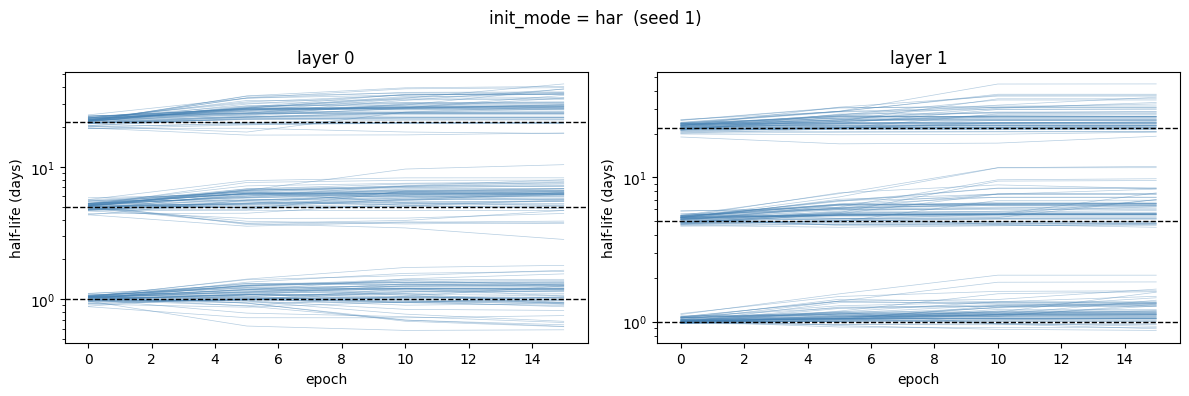

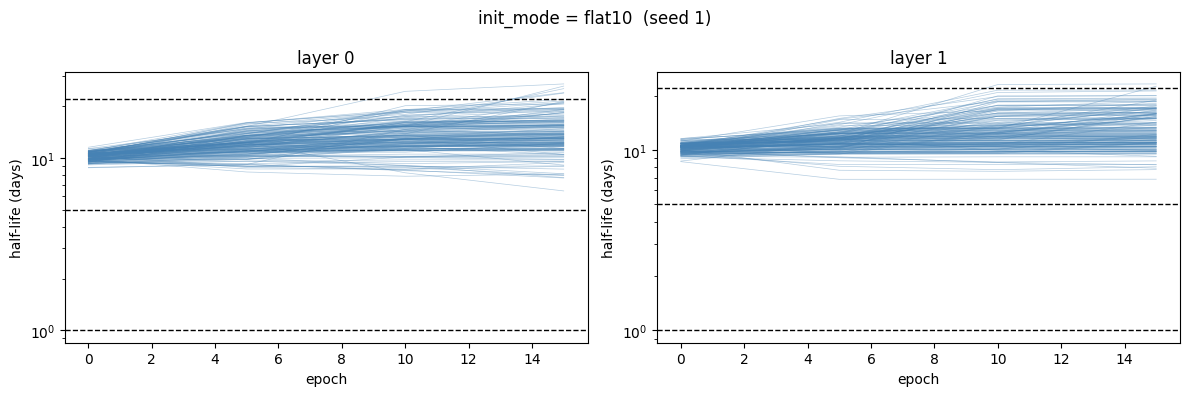

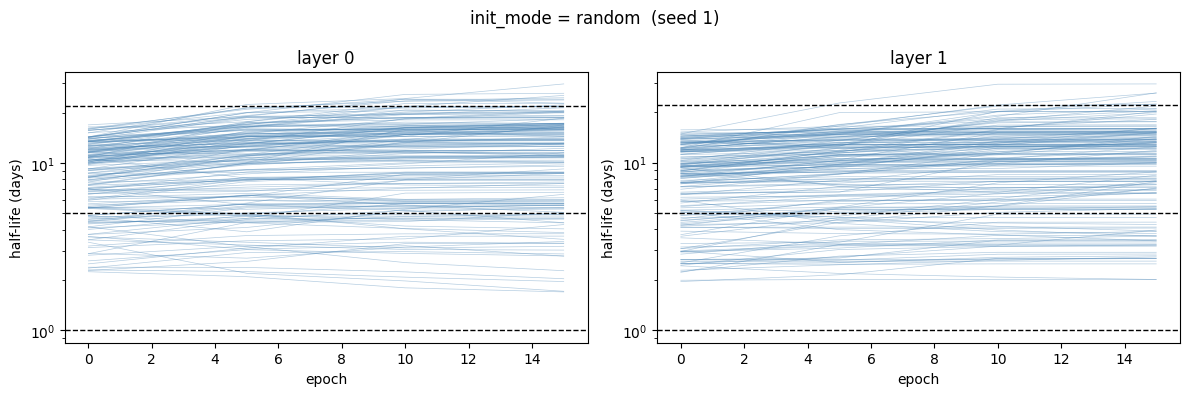

In [13]:
def plot_trajectory(mode, traj):
    if not traj:
        print(f"no trajectory recorded for {mode}"); return
    stacked = torch.stack(traj).numpy()                      # [T, n_layer, d]
    n_layer = stacked.shape[1]
    epochs = [5 * i for i in range(len(traj))]
    fig, axes = plt.subplots(1, n_layer, figsize=(6 * n_layer, 4), squeeze=False)
    for li in range(n_layer):
        ax = axes[0, li]
        for ch in range(stacked.shape[2]):
            ax.plot(epochs, stacked[:, li, ch], lw=0.5, alpha=0.4, color="steelblue")
        for ref in HL_REF:
            ax.axhline(ref, ls="--", color="black", lw=1)
        ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("half-life (days)")
        ax.set_title(f"layer {li}")
    fig.suptitle(f"init_mode = {mode}  (seed {SEEDS[0]})")
    plt.tight_layout(); plt.show()

for mode in INIT_MODES:
    plot_trajectory(mode, trajs[mode])


In [14]:
def summarize_finals(mode, final_hls):
    stacked = torch.stack(final_hls)                          # [n_seeds, n_layer, d]
    n_layer, d = stacked.shape[1], stacked.shape[2]
    print(f"--- init_mode={mode} ---")
    if mode == "har":
        k = max(d // 3, 1)
        for li in range(n_layer):
            for name, sl in zip(("1d", "5d", "22d"), (slice(0, k), slice(k, 2 * k), slice(2 * k, d))):
                v = stacked[:, li, sl].flatten().numpy()       # pooled across seeds
                q1, q2, q3 = np.percentile(v, [25, 50, 75])
                print(f"  layer {li} | init {name:>3s} -> median {q2:6.2f}  (IQR {q1:.2f}\u2013{q3:.2f})  [min {v.min():.2f}, max {v.max():.2f}]")
    else:
        for li in range(n_layer):
            v = stacked[:, li, :].flatten().numpy()            # pooled across seeds, no init-group structure
            q1, q2, q3 = np.percentile(v, [25, 50, 75])
            print(f"  layer {li} | all channels -> median {q2:6.2f}  (IQR {q1:.2f}\u2013{q3:.2f})  [min {v.min():.2f}, max {v.max():.2f}]")
            migr = {name: float(np.mean(np.abs(v - ref) <= 0.3 * ref)) for ref, name in zip(HL_REF, ("1d", "5d", "22d"))}
            print("    migration score (fraction within \u00b130% of scale): " +
                  ", ".join(f"{name}={frac*100:.0f}%" for name, frac in migr.items()))

for mode in INIT_MODES:
    summarize_finals(mode, finals[mode])


--- init_mode=har ---
  layer 0 | init  1d -> median   1.03  (IQR 0.98–1.07)  [min 0.64, max 1.55]
  layer 0 | init  5d -> median   5.22  (IQR 4.96–5.61)  [min 4.35, max 11.76]
  layer 0 | init 22d -> median  23.29  (IQR 22.14–25.02)  [min 16.17, max 36.86]
  layer 1 | init  1d -> median   1.04  (IQR 1.00–1.09)  [min 0.88, max 1.95]
  layer 1 | init  5d -> median   5.26  (IQR 5.00–5.56)  [min 3.83, max 9.06]
  layer 1 | init 22d -> median  22.88  (IQR 21.96–23.87)  [min 19.02, max 33.23]
--- init_mode=flat10 ---
  layer 0 | all channels -> median  10.17  (IQR 9.74–10.56)  [min 8.58, max 13.04]
    migration score (fraction within ±30% of scale): 1d=0%, 5d=0%, 22d=0%
  layer 1 | all channels -> median  10.21  (IQR 9.82–10.60)  [min 8.43, max 12.77]
    migration score (fraction within ±30% of scale): 1d=0%, 5d=0%, 22d=0%
--- init_mode=random ---
  layer 0 | all channels -> median   8.68  (IQR 5.04–11.64)  [min 1.92, max 17.07]
    migration score (fraction within ±30% of scale): 1d=0%, 